In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
import torch.nn as nn
from pyro.infer import Predictive

###PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

###Forward and Backward Selection
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
import statsmodels.api as sm

# HMC
from pyro.infer import MCMC, NUTS

# variational inference
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoDiagonalNormal, AutoMultivariateNormal
from tqdm.auto import trange
from tqdm.notebook import trange

import matplotlib as mpl
import os
import sys
import math

C:\Users\thumo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sys.path.append(
    r"C:\Users\thumo\OneDrive - Georgia Institute of Technology\Georgia Tech\Semesters\Spring 2025\CSE 8803 IUQ\Project\2-BNN_trained_prior\you-need-a-good-prior"
)

In [3]:
from optbnn.gp.models.gpr import GPR
from optbnn.gp import kernels, mean_functions, priors
from optbnn.bnn.reparam_nets import GaussianMLPReparameterization
from optbnn.bnn.nets.mlp import MLP
from optbnn.bnn.likelihoods import LikGaussian
from optbnn.bnn.priors import FixedGaussianPrior, OptimGaussianPrior
from optbnn.prior_mappers.wasserstein_mapper import MapperWasserstein, WassersteinDistance
from optbnn.utils.rand_generators import MeasureSetGenerator, GridGenerator
from optbnn.utils.normalization import normalize_data
from optbnn.utils.exp_utils import get_input_range
from optbnn.metrics.sampling import compute_rhat_regression
from optbnn.metrics import uncertainty as uncertainty_metrics
from optbnn.sgmcmc_bayes_net.regression_net import RegressionNet
from optbnn.utils import util

### BNN and plot functions

In [33]:
###IGNORE THIS IF YOU DON'T HAVE CUDA
import torch

print("CUDA Available:", torch.cuda.is_available())
print("CUDA Device Count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("CUDA Device Name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")
print(torch.version.cuda)
print(torch.cuda.device_count())

CUDA Available: True
CUDA Device Count: 1
CUDA Device Name: NVIDIA GeForce RTX 4070
Training on device: cuda
11.8
1


In [4]:
class BNN(PyroModule):
    def __init__(self, weight_prior, bias_prior, in_dim=1, out_dim=1, hid_dim=10, n_hid_layers=5):
        '''
        functional model (network architecture):
            a fully connected neural network.

        stochastic model:
            Gaussian prior on weight and bias: p(theta) ~ dist.Normal(0., weight_prior or bias_prior), where weight_prior and bias_prior are learned;
            Gaussian likelihood function: p(y | x, theta) ~ dist.Normal(functional model(x), sigma^2), where sigma ~ dist.Gamma(.5, 1).
        '''
        super().__init__()

        # make sure the dimensions are valid
        assert in_dim > 0 and out_dim > 0 and hid_dim > 0 and n_hid_layers > 0

        # activation function for the whole network, can also be ReLU or LeakyReLU
        self.activation = nn.Tanh()

        # define the layer sizes and the PyroModule layer list
        self.layer_sizes = [in_dim] + n_hid_layers * [hid_dim] + [out_dim]
        layer_list = [PyroModule[nn.Linear](self.layer_sizes[idx - 1], self.layer_sizes[idx]) for idx in
                      range(1, len(self.layer_sizes))]
        self.layers = PyroModule[torch.nn.ModuleList](layer_list)

        # set the probability distribution for each layer's weight and bias
        for layer_idx, layer in enumerate(self.layers):
            layer.weight = PyroSample(dist.Normal(0., weight_prior[layer_idx]).expand([self.layer_sizes[layer_idx + 1], self.layer_sizes[layer_idx]]).to_event(2))
            layer.bias = PyroSample(dist.Normal(0., bias_prior[layer_idx]).expand([self.layer_sizes[layer_idx + 1]]).to_event(1))

    def forward(self, x, y=None):
        # functional model(x)
        # input --> hidden
        x = self.activation(self.layers[0](x))
        # hidden --> hidden
        for layer in self.layers[1:-1]:
            x = self.activation(layer(x))
        # hidden --> output
        mu = self.layers[-1](x).squeeze()

        # sample from P(y | x, \theta)
        sigma = pyro.sample("sigma", dist.Gamma(.5, 1))
        with pyro.plate("data", x.shape[0]):
            # obs is used when quantifying and visualizing the uncertainty of predictions
            obs = pyro.sample("obs", dist.Normal(mu, sigma * sigma), obs=y)
        
        return mu

In [5]:
def plot_predictions(preds, y):
    '''
    Function to visualize the predictions and the uncertainty of predictions.
    '''
    y_pred = preds['obs'].T.detach().numpy().mean(axis=1)
    y_std = preds['obs'].T.detach().numpy().std(axis=1)

    fig, ax = plt.subplots(figsize=(10, 5))

    # decide the range of the y axis based on the number of the labels
    time_idx = np.array(range(len(y)))
    xlims = [time_idx.min() - 0.1, time_idx.max() + 0.1]
    # decide the range of the y axis based on the range of the labels
    ylims = [min(y.min(), y_pred.min()) - 20,
             max(y.max(), y_pred.max()) + 20]
    
    plt.xlim(xlims)
    plt.ylim(ylims)
    plt.xlabel("time", fontsize=20)
    plt.ylabel("closing price", fontsize=20)

    ax.plot(time_idx, y, 'ko', markersize=1, label="observations")
    ax.plot(time_idx, y_pred, '-', linewidth=0.5, color="#408765", label="predictive mean")
    ax.fill_between(time_idx, y_pred - 2 * y_std, y_pred + 2 * y_std, alpha=0.6, color='#86cfac', zorder=0)

    plt.legend(loc=4, fontsize=15, frameon=False)

In [6]:
def plot_uncertainty(preds, y):
    '''
    Function to visualize only the uncertainty.
    '''
    fig, ax = plt.subplots(figsize=(10, 5))

    time_idx = np.array(range(len(y)))
    y_std = preds['obs'].T.detach().numpy().std(axis=1)

    xlims = [time_idx.min() - 0.1, time_idx.max() + 0.1]
    ylims = [y_std.min() - 0.5, y_std.max() + 0.5]

    plt.xlim(xlims)
    plt.ylim(ylims)
    plt.xlabel("time", fontsize=20)
    plt.ylabel("std of closing price", fontsize=20)

    ax.plot(time_idx, y_std, 'ko', markersize=1, label="std of predictions")
    ax.plot(time_idx, y_std, '-', linewidth=0.5, color="#408765")

    plt.legend(loc=4, fontsize=15, frameon=False)

#### Prior BNN: ATOS

In [78]:
df_pre_atos = pd.read_csv("pregdprApril2016_ATOS.csv")
df_pre_atos.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,target
0,101332527.0,64.06,10.0,1.0,1.059301,101332527.0,64.69,10.0,1.0,1.059301,...,64.90,10.0,1.0,1.059301,101332527.0,66.81,10.0,1.0,1.059301,66.436752
1,101332527.0,64.69,10.0,1.0,1.059301,101332527.0,64.55,10.0,1.0,1.059301,...,66.81,10.0,1.0,1.059301,101332527.0,67.62,10.0,1.0,1.059301,66.193655
2,101332527.0,64.55,10.0,1.0,1.059301,101332527.0,64.90,10.0,1.0,1.059301,...,67.62,10.0,1.0,1.059301,101332527.0,67.74,10.0,1.0,1.059301,67.025057
3,101332527.0,64.90,10.0,1.0,1.059301,101332527.0,66.81,10.0,1.0,1.059301,...,67.74,10.0,1.0,1.059301,101332527.0,68.26,10.0,1.0,1.059301,66.396596
4,101332527.0,66.81,10.0,1.0,1.059301,101332527.0,67.62,10.0,1.0,1.059301,...,68.26,10.0,1.0,1.059301,101332527.0,68.19,10.0,1.0,1.059301,66.402495


In [79]:
# Get both X and y from the DataFrame
X_pre_atos = df_pre_atos.iloc[:, :-1].values
y_pre_atos = df_pre_atos["target"].values

# Combine them into a single mask
valid_mask = ~np.isnan(X_pre_atos).any(axis=1) & ~np.isnan(y_pre_atos)

# Apply the same mask to both
X_pre_atos = X_pre_atos[valid_mask]
y_pre_atos = y_pre_atos[valid_mask]

In [80]:
X_pre_atos, X_pre_atos.shape, type(X_pre_atos)

(array([[1.01332527e+08, 6.40600000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.05930099e+00],
        [1.01332527e+08, 6.46900000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.05930099e+00],
        [1.01332527e+08, 6.45500000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.05930099e+00],
        ...,
        [1.03523793e+08, 7.57200000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.07144546e+00],
        [1.03523793e+08, 7.37800000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.07144546e+00],
        [1.03523793e+08, 7.65800000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.07144546e+00]]),
 (269, 25),
 numpy.ndarray)

In [81]:
y_pre_atos, y_pre_atos.shape, type(y_pre_atos)

(array([66.43675231, 66.19365458, 67.02505736, 66.39659582, 66.40249545,
        65.85739353, 65.54672011, 66.21159184, 68.41901454, 69.74057369,
        69.9028742 , 69.72543921, 70.05059772, 70.26310226, 72.11335583,
        70.8169484 , 70.63240904, 71.36171321, 70.5225532 , 71.1529422 ,
        70.90081565, 71.59274727, 71.69760722, 71.93920253, 72.26829442,
        71.81241305, 71.81496342, 71.90563127, 70.25588824, 70.34837211,
        70.01436712, 70.26620954, 70.62011494, 70.14662914, 70.18333708,
        71.42108796, 72.23617361, 71.24882999, 70.62118695, 70.72686636,
        70.34700624, 69.93468145, 70.03169224, 70.20163028, 70.28250355,
        70.00368636, 70.80373285, 69.25062159, 68.95814854, 68.55657803,
        70.29077194, 70.33890812, 69.89093614, 70.82323773, 70.43948262,
        70.01389438, 71.00155318, 70.1209522 , 70.57965374, 71.11391632,
        70.92466599, 71.17780136, 71.63589014, 72.61265501, 72.56221672,
        71.38897184, 71.3463526 , 70.48971421, 70.5

In [82]:
noise_var = 0.1
n_units = 128
n_hidden = 1
activation_fn = "tanh"
num_iters = 500  # Number of iteterations of Wasserstein optimization
lr = 0.05        # The learning rate
n_samples = 128  # The mini-batch size
out_dir = "./exp/gdpr/optim_gaussian"

X_pre_n, y_pre_n, y_mean, y_std = normalize_data(X_pre_atos, y_pre_atos)
x_min, x_max = get_input_range(X_pre_atos, y_pre_atos)
epsilon = 1e-6
x_min = np.minimum(x_min, x_max - epsilon)
input_dim, output_dim = int(X_pre_atos.shape[-1]), 1
    
# Initialize the measurement set generator
rand_generator = MeasureSetGenerator(X_pre_n, x_min, x_max, 0.7)

# Initialize the mean and covariance function of the target hierarchical GP prior
mean = mean_functions.Zero()
    
lengthscale = math.sqrt(2. * input_dim)
variance = 1.
kernel = kernels.RBF(input_dim=input_dim,
                     lengthscales=torch.tensor([lengthscale], dtype=torch.double),
                     variance=torch.tensor([variance], dtype=torch.double), ARD=True)

# Place hyper-priors on lengthscales and variances
kernel.lengthscales.prior = priors.LogNormal(
    torch.ones([input_dim]) * math.log(lengthscale),
    torch.ones([input_dim]) * 1.)
kernel.variance.prior = priors.LogNormal(
    torch.ones([1]) * 0.1,
    torch.ones([1]) * 1.)
        
# Initialize the GP model
gp = GPR(X=torch.from_numpy(X_pre_n), Y=torch.from_numpy(y_pre_n).reshape([-1, 1]),
             kern=kernel, mean_function=mean)
gp.likelihood.variance.set(noise_var)
    
# Initialize tunable MLP prior
hidden_dims = [n_units] * n_hidden
mlp_reparam = GaussianMLPReparameterization(input_dim, output_dim,
    hidden_dims, activation_fn, scaled_variance=True)
    
mapper = MapperWasserstein(gp, mlp_reparam, rand_generator, out_dir=out_dir,
                               output_dim=output_dim, n_data=100,
                               wasserstein_steps=(0, 300), ###more than 200
                               wasserstein_lr=0.02,
                               logger=None, wasserstein_thres=0.1,
                               n_gpu=1, gpu_gp=True) ##Change GPU if you don't have CUDA; same thing for the post training
    
w_hist = mapper.optimize(num_iters=num_iters, n_samples=n_samples,
                             lr=lr, print_every=10, save_ckpt_every=10, debug=True)

print("----" * 20)

C:\Users\thumo\OneDrive - Georgia Institute of Technology\Georgia Tech\Semesters\Spring 2025\CSE 8803 IUQ\Project\2-BNN_trained_prior\you-need-a-good-prior\optbnn\gp\parameter.py:63: UserWarning: An output with one or more elements was resized since it had shape [1], which does not match the required output shape []. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Resize.cpp:37.)
  return torch.log(torch.exp(t) - 1, out=out)


>>> Iteration #   1: Wasserstein Dist 16.1353
>>> Iteration #  10: Wasserstein Dist 7.8594
>>> Iteration #  20: Wasserstein Dist 7.8568
>>> Iteration #  30: Wasserstein Dist 6.0293
>>> Iteration #  40: Wasserstein Dist 6.9889
>>> Iteration #  50: Wasserstein Dist 6.5366
>>> Iteration #  60: Wasserstein Dist 8.2993
>>> Iteration #  70: Wasserstein Dist 7.5253
>>> Iteration #  80: Wasserstein Dist 6.7018
>>> Iteration #  90: Wasserstein Dist 5.5030
>>> Iteration # 100: Wasserstein Dist 8.6584
>>> Iteration # 110: Wasserstein Dist 5.4482
>>> Iteration # 120: Wasserstein Dist 5.6628
>>> Iteration # 130: Wasserstein Dist 6.4641
>>> Iteration # 140: Wasserstein Dist 4.9811
>>> Iteration # 150: Wasserstein Dist 6.5720
>>> Iteration # 160: Wasserstein Dist 5.6347
>>> Iteration # 170: Wasserstein Dist 5.4989
>>> Iteration # 180: Wasserstein Dist 4.0875
>>> Iteration # 190: Wasserstein Dist 4.6105
>>> Iteration # 200: Wasserstein Dist 4.1764
>>> Iteration # 210: Wasserstein Dist 4.5529
>>> Itera

In [83]:
for name, param in mlp_reparam.named_parameters():
    print(f"parameter name: {name}, parameter shape: {param}")

parameter name: layers.0.W_std, parameter shape: Parameter containing:
tensor([7.2279], device='cuda:0', requires_grad=True)
parameter name: layers.0.b_std, parameter shape: Parameter containing:
tensor([8.9906], device='cuda:0', requires_grad=True)
parameter name: output_layer.W_std, parameter shape: Parameter containing:
tensor([0.9170], device='cuda:0', requires_grad=True)
parameter name: output_layer.b_std, parameter shape: Parameter containing:
tensor([-2.6787], device='cuda:0', requires_grad=True)


In [84]:
def maintain_positivity(x):
    '''
    maintain the positivity of weight and bias standard derivations
    '''
    return np.log(1 + np.exp(x))

pre_weight_prior = [maintain_positivity(3.6905), maintain_positivity(1.3724)]
pre_bias_prior = [maintain_positivity(2.9497), maintain_positivity(-0.8432)]

In [85]:
# clear parameters to ensure every training start from scratch
pyro.clear_param_store()

# set up BNN
model_VI = BNN(pre_weight_prior, pre_bias_prior, in_dim=25, out_dim=1, hid_dim=128, n_hid_layers=1)

#mean_field_guide = AutoDiagonalNormal(model_VI) # mean field variational inference
guide = AutoMultivariateNormal(model_VI) # use multivariate normal with full covariance to approxiamte posterior

# apply SGD to maximizing the ELBO
optimizer = pyro.optim.Adam({"lr": 0.001})
svi = SVI(model_VI, guide, optimizer, loss=Trace_ELBO())

# # clear parameters to avoid influencing others
pyro.clear_param_store()

In [86]:
%time
num_epochs = 20000 # number of training epoches, 10000 now for quick test: 25000
progress_bar = trange(num_epochs) # show progress bar (only for visualization purpose)

X_pre_n_tensor = torch.tensor(X_pre_n, dtype=torch.float)
y_pre_n_tensor = torch.tensor(y_pre_n, dtype=torch.float)

for epoch in progress_bar:
    loss = svi.step(X_pre_n_tensor, y_pre_n_tensor)
    progress_bar.set_postfix(loss=f"{loss / X_pre_n.shape[0]:.3f}")
    if epoch % 1000 == 0:
        print("[iteration %04d] loss: %.3f" % (epoch + 1, loss / X_pre_n.shape[0])) #28.850 at 10K steps

CPU times: total: 0 ns
Wall time: 0 ns


  0%|          | 0/20000 [00:00<?, ?it/s]

[iteration 0001] loss: 168.906
[iteration 1001] loss: 389.889
[iteration 2001] loss: 48.813
[iteration 3001] loss: 38.582
[iteration 4001] loss: 36.335
[iteration 5001] loss: 29.693
[iteration 6001] loss: 61.706
[iteration 7001] loss: 27.597
[iteration 8001] loss: 25.461
[iteration 9001] loss: 22.944
[iteration 10001] loss: 20.570
[iteration 11001] loss: 19.617
[iteration 12001] loss: 16.481
[iteration 13001] loss: 15.147
[iteration 14001] loss: 14.678
[iteration 15001] loss: 13.265
[iteration 16001] loss: 12.953
[iteration 17001] loss: 12.858
[iteration 18001] loss: 12.453
[iteration 19001] loss: 12.090


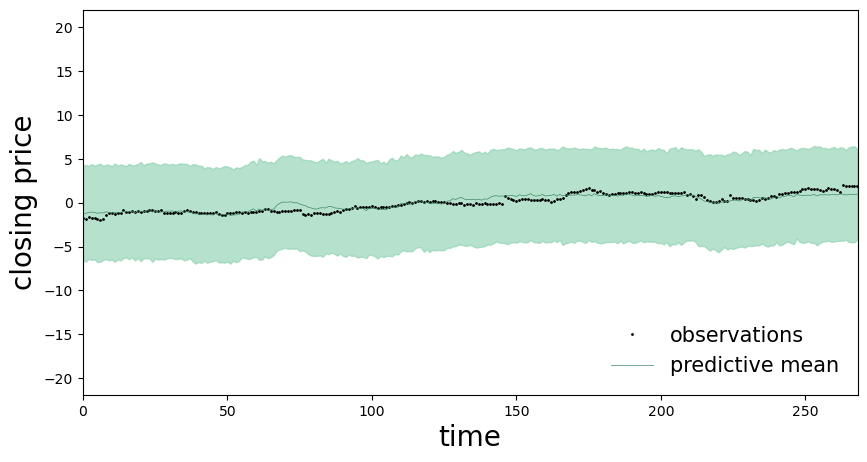

In [87]:
predictive = Predictive(model_VI, guide=guide, num_samples=1000)
preds = predictive(X_pre_n_tensor)
plot_predictions(preds, y_pre_n_tensor)

In [88]:
#RMSE
pred_samples = preds["obs"]
pred_mean = pred_samples.mean(dim=0) 
y_true = y_pre_n_tensor
rmse = torch.sqrt(torch.mean((pred_mean - y_true) ** 2))
print(rmse)

tensor(0.4557)


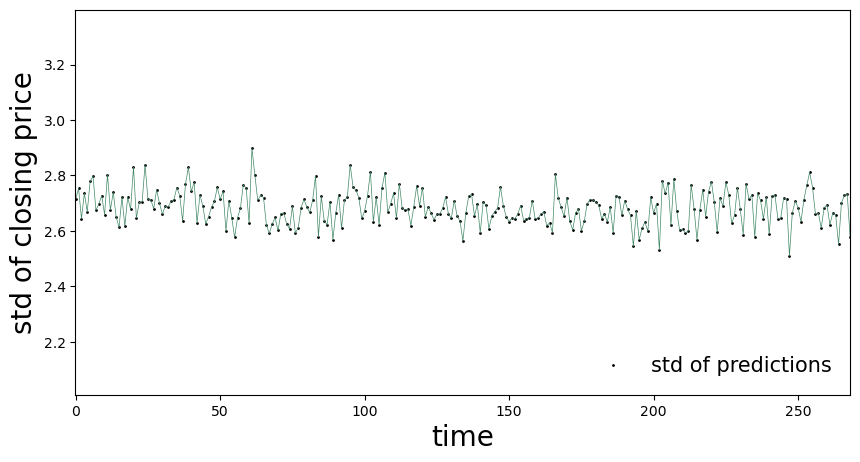

In [89]:
plot_uncertainty(preds, y_pre_n_tensor)

#### Posterior BNN: ATOS

In [90]:
df_post_atos = pd.read_csv("postgdprMay2018_ATOS.csv")

In [91]:
# Extract values
X_post_atos = df_post_atos.iloc[:, :-1].values
y_post_atos = df_post_atos["target"].values

# Create a mask for rows without NaNs in either X or y
valid_mask = ~np.isnan(X_post_atos).any(axis=1) & ~np.isnan(y_post_atos)

# Apply mask to both X and y
X_post_atos = X_post_atos[valid_mask]
y_post_atos = y_post_atos[valid_mask]

In [92]:
X_post_atos, X_post_atos.shape, type(X_post_atos)

(array([[1.05598479e+08, 1.17150000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.11602484e+00],
        [1.05598479e+08, 1.17150000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.11602484e+00],
        [1.05598479e+08, 1.17600000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.11602484e+00],
        ...,
        [1.09195114e+08, 7.40200000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.51014779e+00],
        [1.09195114e+08, 7.45400000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.51014779e+00],
        [1.09195114e+08, 7.53800000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.51014779e+00]]),
 (398, 25),
 numpy.ndarray)

In [93]:
y_post_atos, y_post_atos.shape, type(y_post_atos)

(array([118.72531657, 118.9868471 , 117.83229622, 122.45415181,
        122.84978913, 123.35538611, 122.83718715, 122.6852506 ,
        123.69696969, 122.86327143, 122.06777352, 121.85496098,
        120.24495789, 118.52688539, 118.87607238, 119.76789082,
        118.5058052 , 117.77121331, 118.30788725, 117.90028815,
        118.60271875, 121.6693244 , 123.30854384, 123.41987253,
        123.00995474, 123.850324  , 124.04911303, 123.26956873,
        123.16291628, 122.77185184, 114.56244754, 113.9740558 ,
        116.50418357, 113.83466109, 114.34495618, 112.90369044,
        112.08357149, 109.96210459, 111.11507464, 110.5276422 ,
        109.88335263,  97.84897612,  98.66370222,  98.42864715,
         96.97043091,  98.29420843,  98.6726412 ,  98.1022985 ,
         98.69004834,  99.38641308,  99.94324463, 101.55322457,
        101.06621525, 101.10770189, 102.64963817, 102.19028834,
        103.02733173, 103.33829144, 103.96813983, 104.30942094,
        102.72416141, 103.82106233, 102.

In [94]:
noise_var = 0.1
n_units = 128
n_hidden = 1
activation_fn = "tanh"
num_iters = 300  # Number of iteterations of Wasserstein optimization
lr = 0.05        # The learning rate
n_samples = 128  # The mini-batch size
out_dir = "./exp/gdpr/optim_gaussian"

X_post_n, y_post_n, y_mean, y_std = normalize_data(X_post_atos, y_post_atos)
x_min, x_max = get_input_range(X_post_n, X_post_n)
epsilon = 1e-6
x_min = np.minimum(x_min, x_max - epsilon)
input_dim, output_dim = int(X_post_atos.shape[-1]), 1
    
# Initialize the measurement set generator
rand_generator = MeasureSetGenerator(X_post_n, x_min, x_max, 0.7)
    
# Initialize the mean and covariance function of the target hierarchical GP prior
mean = mean_functions.Zero()
    
lengthscale = math.sqrt(2. * input_dim)
variance = 1.
kernel = kernels.RBF(input_dim=input_dim,
                     lengthscales=torch.tensor([lengthscale], dtype=torch.double),
                     variance=torch.tensor([variance], dtype=torch.double), ARD=True)

# Place hyper-priors on lengthscales and variances
kernel.lengthscales.prior = priors.LogNormal(
    torch.ones([input_dim]) * math.log(lengthscale),
    torch.ones([input_dim]) * 1.)
kernel.variance.prior = priors.LogNormal(
    torch.ones([1]) * 0.1,
    torch.ones([1]) * 1.)
        
# Initialize the GP model
gp = GPR(X=torch.from_numpy(X_post_n), Y=torch.from_numpy(y_post_n).reshape([-1, 1]),
             kern=kernel, mean_function=mean)
gp.likelihood.variance.set(noise_var)
    
# Initialize tunable MLP prior
hidden_dims = [n_units] * n_hidden
mlp_reparam = GaussianMLPReparameterization(input_dim, output_dim,
    hidden_dims, activation_fn, scaled_variance=True)
    
mapper = MapperWasserstein(gp, mlp_reparam, rand_generator, out_dir=out_dir,
                               output_dim=output_dim, n_data=100,
                               wasserstein_steps=(0, 300), ##Should be more than 200
                               wasserstein_lr=0.02, ##Change this number
                               logger=None, wasserstein_thres=0.02,
                               n_gpu=1, gpu_gp=True) ##Change GPU if you don't have CUDA; same thing for the PRE training
    
w_hist = mapper.optimize(num_iters=num_iters, n_samples=n_samples,
                             lr=lr, print_every=10, save_ckpt_every=10, debug=True)

print("----" * 20)

C:\Users\thumo\OneDrive - Georgia Institute of Technology\Georgia Tech\Semesters\Spring 2025\CSE 8803 IUQ\Project\2-BNN_trained_prior\you-need-a-good-prior\optbnn\gp\parameter.py:63: UserWarning: An output with one or more elements was resized since it had shape [1], which does not match the required output shape []. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Resize.cpp:37.)
  return torch.log(torch.exp(t) - 1, out=out)


>>> Iteration #   1: Wasserstein Dist 9.5263
>>> Iteration #  10: Wasserstein Dist 1.7840
>>> Iteration #  20: Wasserstein Dist 0.2930
>>> Iteration #  30: Wasserstein Dist 0.7936
>>> Iteration #  40: Wasserstein Dist 1.2958
>>> Iteration #  50: Wasserstein Dist 0.7154
>>> Iteration #  60: Wasserstein Dist 0.7507
>>> Iteration #  70: Wasserstein Dist 1.1944
>>> Iteration #  80: Wasserstein Dist 1.7393
>>> Iteration #  90: Wasserstein Dist 0.0542
>>> Iteration # 100: Wasserstein Dist 0.6542
>>> Iteration # 110: Wasserstein Dist 0.9874
>>> Iteration # 120: Wasserstein Dist -1.0298
>>> Iteration # 130: Wasserstein Dist 0.7017
>>> Iteration # 140: Wasserstein Dist 0.0152
>>> Iteration # 150: Wasserstein Dist -0.4361
>>> Iteration # 160: Wasserstein Dist 0.9698
>>> Iteration # 170: Wasserstein Dist 0.5674
>>> Iteration # 180: Wasserstein Dist 0.4863
>>> Iteration # 190: Wasserstein Dist 0.9777
>>> Iteration # 200: Wasserstein Dist -0.0686
>>> Iteration # 210: Wasserstein Dist 0.5043
>>> Ite

In [95]:
for name, param in mlp_reparam.named_parameters():
    print(f"parameter name: {name}, parameter shape: {param}")

parameter name: layers.0.W_std, parameter shape: Parameter containing:
tensor([3.0885], device='cuda:0', requires_grad=True)
parameter name: layers.0.b_std, parameter shape: Parameter containing:
tensor([2.3948], device='cuda:0', requires_grad=True)
parameter name: output_layer.W_std, parameter shape: Parameter containing:
tensor([1.1694], device='cuda:0', requires_grad=True)
parameter name: output_layer.b_std, parameter shape: Parameter containing:
tensor([-0.5516], device='cuda:0', requires_grad=True)


In [96]:
def maintain_positivity(x):
    '''
    maintain the positivity of weight and bias standard derivations
    '''
    return np.log(1 + np.exp(x))

post_weight_prior = [maintain_positivity(3.1053), maintain_positivity(1.1434)]
post_bias_prior = [maintain_positivity(2.0997), maintain_positivity(-0.6430)]

In [97]:
# clear parameters to ensure every training start from scratch
pyro.clear_param_store()

# set up BNN
model_VI = BNN(post_weight_prior, post_bias_prior, in_dim=25, out_dim=1, hid_dim=128, n_hid_layers=1)

#mean_field_guide = AutoDiagonalNormal(model_VI) # mean field variational inference
guide = AutoMultivariateNormal(model_VI) # use multivariate normal with full covariance to approxiamte posterior

# apply SGD to maximizing the ELBO
optimizer = pyro.optim.Adam({"lr": 0.001})
svi = SVI(model_VI, guide, optimizer, loss=Trace_ELBO())

# # clear parameters to avoid influencing others
pyro.clear_param_store()

In [98]:
num_epochs = 20000 # number of training epoches, 10000 now for quick test
progress_bar = trange(num_epochs) # show progress bar (only for visualization purpose)

X_post_n_tensor = torch.tensor(X_post_n, dtype=torch.float)
y_post_n_tensor = torch.tensor(y_post_n, dtype=torch.float)

for epoch in progress_bar:
    loss = svi.step(X_post_n_tensor, y_post_n_tensor)
    progress_bar.set_postfix(loss=f"{loss / X_post_n.shape[0]:.3f}")
    if epoch % 1000 == 0:
        print("[iteration %04d] loss: %.3f" % (epoch + 1, loss / X_post_n.shape[0])) #24.621

  0%|          | 0/20000 [00:00<?, ?it/s]

[iteration 0001] loss: 1187.391
[iteration 1001] loss: 143.406
[iteration 2001] loss: 2139.064
[iteration 3001] loss: 277.169
[iteration 4001] loss: 483.002
[iteration 5001] loss: 673.119
[iteration 6001] loss: 145.656
[iteration 7001] loss: 28.867
[iteration 8001] loss: 28.860
[iteration 9001] loss: 30.772
[iteration 10001] loss: 84.732
[iteration 11001] loss: 21.106
[iteration 12001] loss: 19.739
[iteration 13001] loss: 19.880
[iteration 14001] loss: 20.502
[iteration 15001] loss: 18.984
[iteration 16001] loss: 18.795
[iteration 17001] loss: 18.878
[iteration 18001] loss: 16.579
[iteration 19001] loss: 16.003


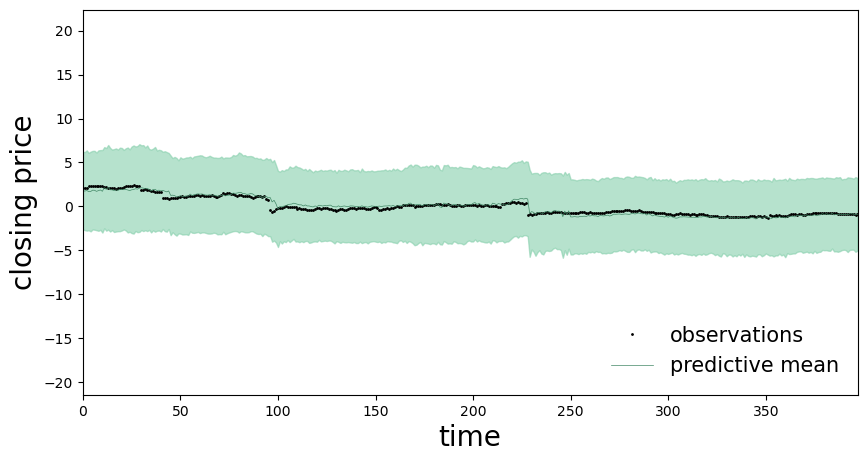

In [99]:
predictive = Predictive(model_VI, guide=guide, num_samples=1000)
preds = predictive(X_post_n_tensor)
plot_predictions(preds, y_post_n_tensor)

In [100]:
##RMSE
pred_samples = preds["obs"]
pred_mean = pred_samples.mean(dim=0)
# Calculate RMSE
y_true = y_post_n_tensor
rmse = torch.sqrt(torch.mean((pred_mean - y_true) ** 2))
print(rmse)

tensor(0.3129)


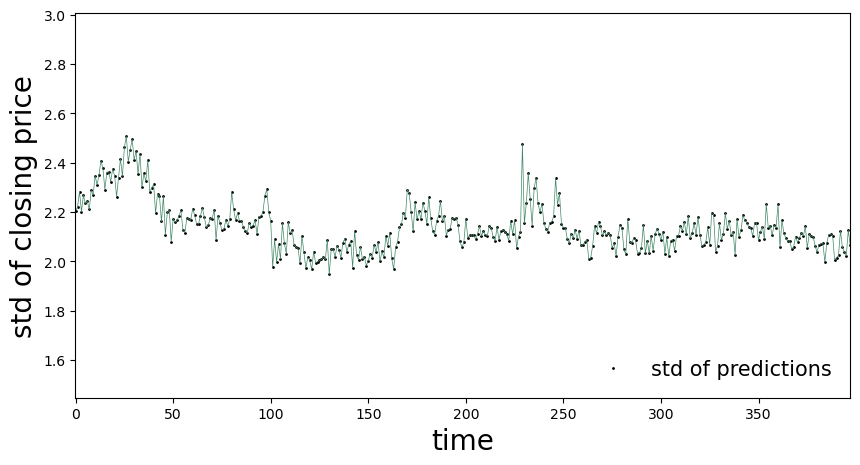

In [101]:
plot_uncertainty(preds, y_post_n)